## Análisis bivariable de datos

### By:
Maria Camila Sepúlveda Torres

### Date:
2024-08-21

### Description:

El análisis bivariable estudia la relación entre dos variables simultáneamente, buscando identificar asociaciones, correlaciones o dependencias entre ellas.

En este análisis se estudiará principalmente la relación entre las variables disponibles y la variable objetivo `Chance of Admit`, con el fin de identificar cuáles atributos presentan una mayor asociación con la probabilidad de admisión.


## 📚 Import  libraries

In [35]:
# base libraries for data science
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.simplefilter(action="ignore", category=FutureWarning)

In [36]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [37]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Pandas version:  3.0.5


## 💾 Load data

In [38]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admission_type_fixed.parquet",
    engine="pyarrow",
)

In [39]:
admission_df["University Rating"] = pd.Categorical(
    admission_df["University Rating"],
    categories=[1, 2, 3, 4, 5],
    ordered=True,
)

admission_df["SOP"] = pd.Categorical(
    admission_df["SOP"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

admission_df["LOR"] = pd.Categorical(
    admission_df["LOR"],
    categories=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    ordered=True,
)

In [40]:
admission_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          612 non-null    Int16   
 1   TOEFL Score        604 non-null    Int16   
 2   University Rating  617 non-null    category
 3   SOP                607 non-null    category
 4   LOR                615 non-null    category
 5   CGPA               621 non-null    float64 
 6   Research           594 non-null    boolean 
 7   Chance of Admit    623 non-null    float64 
dtypes: Int16(2), boolean(1), category(3), float64(2)
memory usage: 17.3 KB


## 📈 Análisis Bivariable

Es importante analizar la relación entre la variable objetivo y las demás variables del conjunto de datos.

La variable objetivo es `Chance of Admit`.

### Variable objetivo vs variables numéricas

#### Chance of Admit vs GRE Score

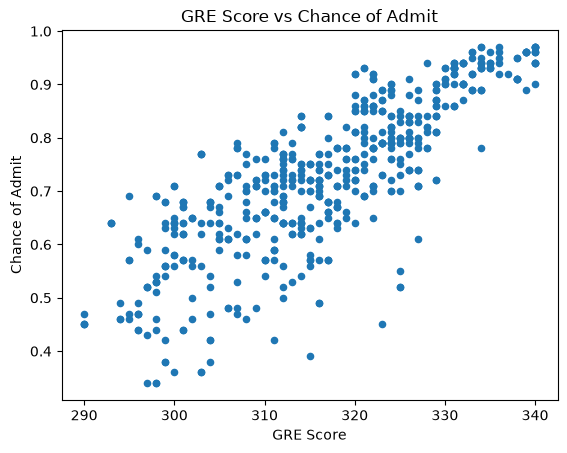

In [41]:
# gráfico de dispersión de GRE Score vs Chance of Admit

admission_df.plot(
    kind="scatter",
    x="GRE Score",
    y="Chance of Admit",
    title="GRE Score vs Chance of Admit",
);

##### Correlación

In [42]:
# correlación entre GRE Score y Chance of Admit
admission_df[["GRE Score", "Chance of Admit"]].corr()

,GRE Score,Chance of Admit
GRE Score,1.00,0.82
Chance of Admit,0.82,1.00


#### Análisis

Se observa una relación positiva entre `GRE Score` y `Chance of Admit`. En el gráfico de dispersión se evidencia que, en general, a medida que aumenta el puntaje GRE también aumenta la probabilidad de admisión.

La correlación entre ambas variables es de 0.82, lo que indica una relación lineal positiva fuerte. Por lo tanto, `GRE Score` podría ser una variable importante para explicar o predecir `Chance of Admit`.

Aunque se observan algunos puntos alejados del patrón general, la tendencia positiva entre ambas variables es clara.

#### Chance of Admit vs TOEFL Score

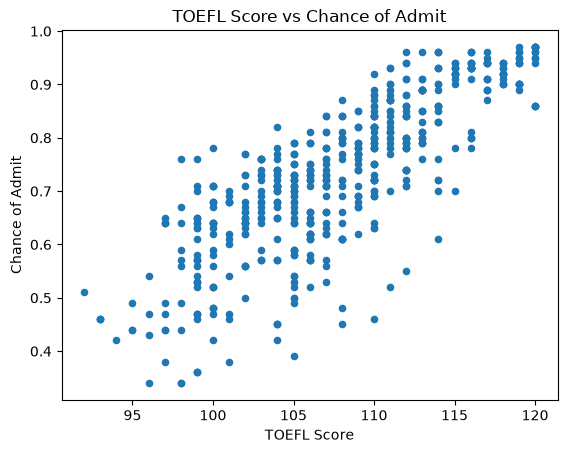

In [43]:
# gráfico de dispersión de TOEFL Score vs Chance of Admit

admission_df.plot(
    kind="scatter",
    x="TOEFL Score",
    y="Chance of Admit",
    title="TOEFL Score vs Chance of Admit",
);

##### Correlación

In [44]:
# correlación entre TOEFL Score y Chance of Admit
admission_df[["TOEFL Score", "Chance of Admit"]].corr()

,TOEFL Score,Chance of Admit
TOEFL Score,1.00,0.81
Chance of Admit,0.81,1.00


#### Análisis

Se observa una relación positiva entre `TOEFL Score` y `Chance of Admit`. En el gráfico de dispersión se evidencia que, en general, a medida que aumenta el puntaje TOEFL también aumenta la probabilidad de admisión.

La correlación entre ambas variables es de 0.81, lo que indica una relación lineal positiva fuerte. Por lo tanto, `TOEFL Score` podría ser una variable importante para explicar o predecir `Chance of Admit`.

Aunque se observan algunos puntos alejados del patrón general, la tendencia positiva entre ambas variables es clara.

#### Chance of Admit vs CGPA

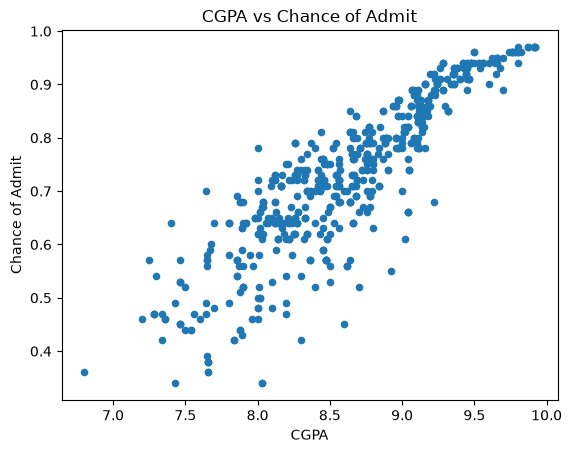

In [45]:
# gráfico de dispersión de CGPA vs Chance of Admit

admission_df.plot(
    kind="scatter",
    x="CGPA",
    y="Chance of Admit",
    title="CGPA vs Chance of Admit",
);

##### Correlación

In [46]:
# correlación entre CGPA y Chance of Admit
admission_df[["CGPA", "Chance of Admit"]].corr()

,CGPA,Chance of Admit
CGPA,1.00,0.88
Chance of Admit,0.88,1.00


#### Análisis

Se observa una relación positiva entre `CGPA` y `Chance of Admit`. En el gráfico de dispersión se evidencia que, en general, a medida que aumenta el CGPA también aumenta la probabilidad de admisión.

La correlación entre ambas variables es de 0.88, lo que indica una relación lineal positiva fuerte. Entre las variables numéricas analizadas hasta el momento, `CGPA` presenta la mayor correlación con `Chance of Admit`.

Por lo tanto, `CGPA` podría ser una variable importante para explicar o predecir la probabilidad de admisión.

### Chance of Admit vs University Rating

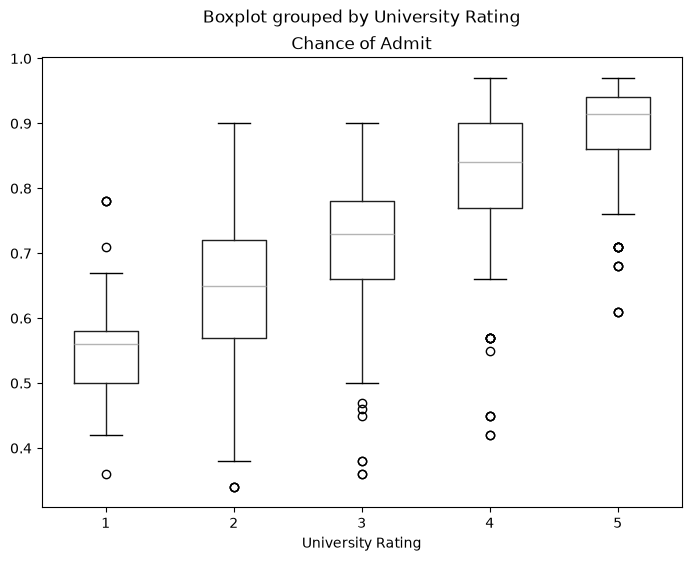

In [47]:
# boxplot de Chance of Admit por University Rating

admission_df.boxplot(
    column="Chance of Admit",
    by="University Rating",
    grid=False,
    figsize=(8, 6),
);

In [48]:
# promedio de Chance of Admit por University Rating

admission_df.groupby(
    "University Rating",
    observed=True
)["Chance of Admit"].mean()

University Rating
1   0.56
2   0.64
3   0.71
4   0.81
5   0.88
Name: Chance of Admit, dtype: float64

#### Análisis

Se observa una relación positiva entre `University Rating` y `Chance of Admit`. A medida que aumenta la categoría de `University Rating`, también aumenta la probabilidad promedio de admisión.

El promedio de `Chance of Admit` aumenta progresivamente desde 0.56 para la categoría 1 hasta 0.88 para la categoría 5. El boxplot también muestra un desplazamiento hacia valores más altos de `Chance of Admit` en las categorías superiores.

Por lo tanto, `University Rating` podría ser una variable importante para explicar o predecir la probabilidad de admisión.

#### Chance of Admit vs SOP

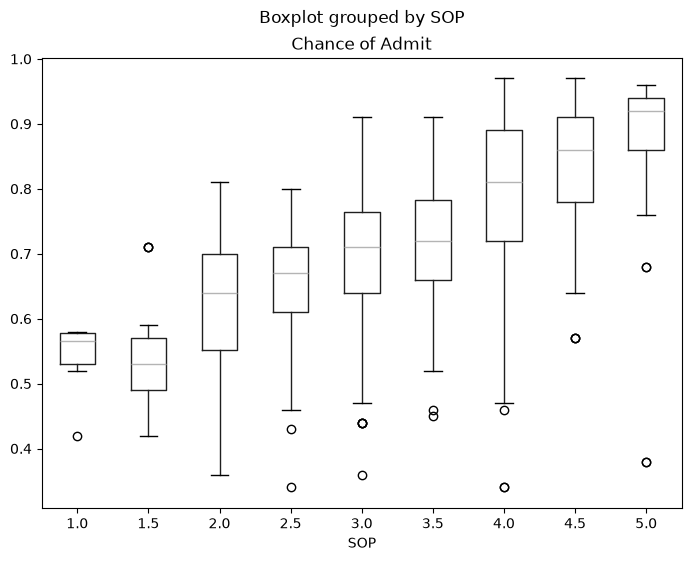

In [49]:
# boxplot de Chance of Admit por SOP

admission_df.boxplot(
    column="Chance of Admit",
    by="SOP",
    grid=False,
    figsize=(8, 6),
);

In [50]:
# promedio de Chance of Admit por SOP

admission_df.groupby(
    "SOP",
    observed=True
)["Chance of Admit"].mean()

SOP
1.00   0.54
1.50   0.54
2.00   0.62
2.50   0.65
3.00   0.68
3.50   0.72
4.00   0.79
4.50   0.84
5.00   0.87
Name: Chance of Admit, dtype: float64

#### Análisis

Se observa una relación positiva entre `SOP` y `Chance of Admit`. En general, a medida que aumenta la valoración de `SOP`, también aumenta la probabilidad promedio de admisión.

El promedio de `Chance of Admit` aumenta desde aproximadamente 0.54 para las categorías más bajas hasta 0.87 para la categoría 5.0. El boxplot también muestra un desplazamiento hacia valores más altos de `Chance of Admit` en las categorías superiores.

Por lo tanto, `SOP` podría ser una variable útil para explicar o predecir la probabilidad de admisión.

#### Chance of Admit vs LOR

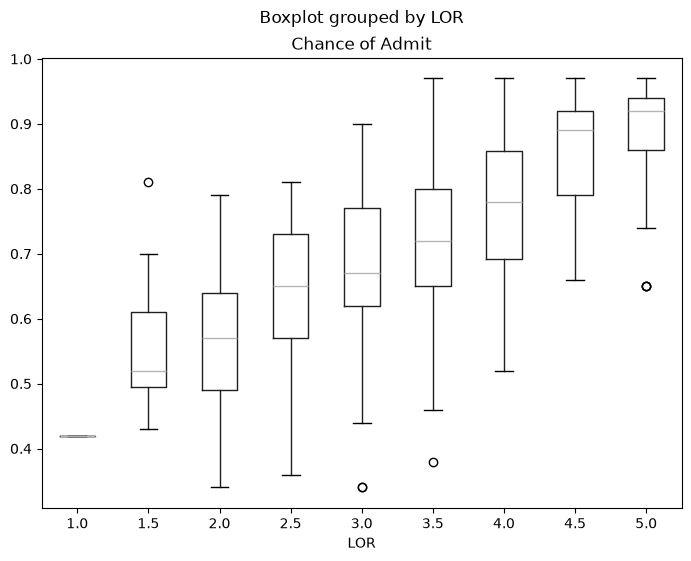

In [51]:
# boxplot de Chance of Admit por LOR

admission_df.boxplot(
    column="Chance of Admit",
    by="LOR",
    grid=False,
    figsize=(8, 6),
);

In [52]:
# promedio de Chance of Admit por LOR

admission_df.groupby(
    "LOR",
    observed=True
)["Chance of Admit"].mean()

LOR
1.00   0.42
1.50   0.57
2.00   0.57
2.50   0.63
3.00   0.68
3.50   0.73
4.00   0.78
4.50   0.86
5.00   0.88
Name: Chance of Admit, dtype: float64

#### Análisis

Se observa una relación positiva entre `LOR` y `Chance of Admit`. En general, a medida que aumenta la valoración de `LOR`, también aumenta la probabilidad promedio de admisión.

El promedio de `Chance of Admit` aumenta progresivamente desde las categorías más bajas hasta alcanzar 0.88 para la categoría 5.0. El boxplot también muestra un desplazamiento hacia valores más altos de `Chance of Admit` a medida que aumenta `LOR`.

Se debe tener en cuenta que algunas categorías presentan pocas observaciones, especialmente `LOR = 1.0`, por lo que sus resultados deben interpretarse con precaución.

Por lo tanto, `LOR` podría ser una variable útil para explicar o predecir la probabilidad de admisión.

#### Chance of Admit vs Research

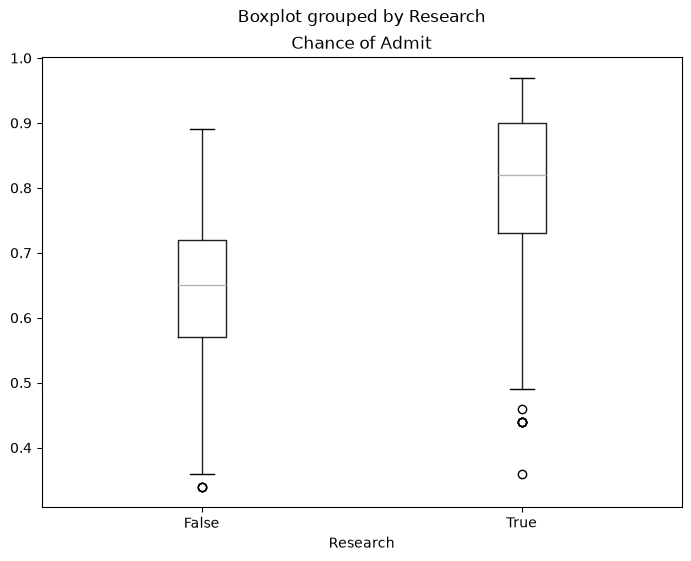

In [53]:
# boxplot de Chance of Admit por Research

admission_df.boxplot(
    column="Chance of Admit",
    by="Research",
    grid=False,
    figsize=(8, 6),
);

In [54]:
# promedio de Chance of Admit por Research

admission_df.groupby(
    "Research",
    observed=True
)["Chance of Admit"].mean()

Research
False   0.64
True    0.80
Name: Chance of Admit, dtype: float64

#### Análisis

Se observa una diferencia en `Chance of Admit` según la variable `Research`. Los estudiantes con experiencia en investigación (`True`) presentan una probabilidad promedio de admisión de 0.80, mientras que los estudiantes sin experiencia en investigación (`False`) presentan un promedio de 0.64.

El boxplot también muestra que la distribución de `Chance of Admit` para los estudiantes con experiencia en investigación se encuentra desplazada hacia valores más altos.

Por lo tanto, `Research` podría ser una variable útil para explicar o predecir la probabilidad de admisión.

## Correlación entre variables numéricas

In [55]:
# seleccionar variables numéricas
numeric_columns = [
    "GRE Score",
    "TOEFL Score",
    "CGPA",
    "Chance of Admit"
]

# matriz de correlación
admission_df[numeric_columns].corr().round(2)

,GRE Score,TOEFL Score,CGPA,Chance of Admit
GRE Score,1.00,0.85,0.84,0.82
TOEFL Score,0.85,1.00,0.84,0.81
CGPA,0.84,0.84,1.00,0.88
Chance of Admit,0.82,0.81,0.88,1.00


### Matriz de correlación

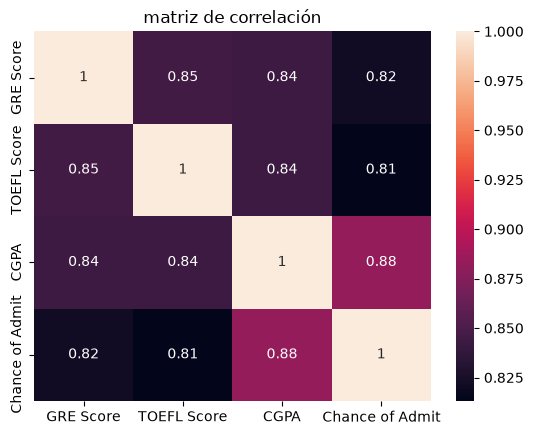

In [56]:
# matriz de correlación

correlation_matrix = admission_df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("matriz de correlación")
plt.show()

## University Rating vs SOP

In [57]:
# University Rating VS SOP

pd.crosstab(
    admission_df["University Rating"],
    admission_df["SOP"]
)

SOP,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50,5.00
University Rating,,,,,,,,,
1,5,13,7,2,2,4,0,0,0
2,1,12,23,43,35,15,16,9,0
3,0,0,18,12,40,75,37,8,5
4,0,4,3,3,6,10,31,44,16
5,0,0,0,0,6,4,26,26,40


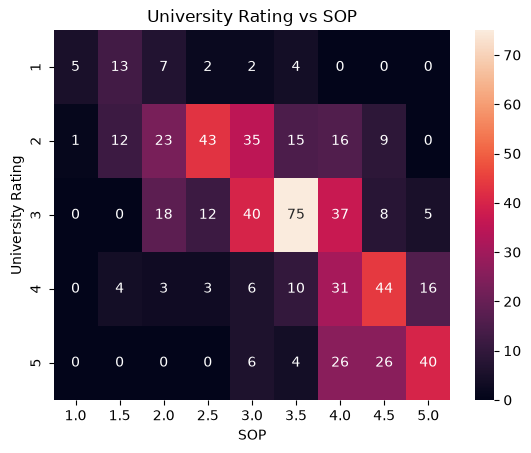

In [58]:
# relación entre University Rating y SOP

university_sop = pd.crosstab(
    admission_df["University Rating"],
    admission_df["SOP"]
)

sns.heatmap(
    university_sop,
    annot=True,
    fmt="d"
)

plt.title("University Rating vs SOP")
plt.show()

## University Rating vs LOR

In [59]:
# tabla cruzada entre University Rating y LOR

pd.crosstab(
    admission_df["University Rating"],
    admission_df["LOR"]
)

LOR,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50,5.00
University Rating,,,,,,,,,
1,1,4,14,4,6,3,0,0,0
2,0,2,22,27,49,35,20,0,0
3,0,1,7,17,67,46,38,13,8
4,0,0,1,10,8,14,37,33,14
5,0,0,0,0,4,16,23,31,34


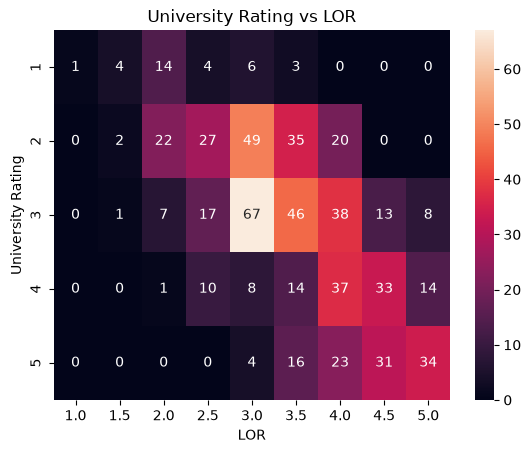

In [60]:
# relación entre University Rating y LOR

university_lor = pd.crosstab(
    admission_df["University Rating"],
    admission_df["LOR"]
)

sns.heatmap(
    university_lor,
    annot=True,
    fmt="d"
)

plt.title("University Rating vs LOR")
plt.show()

## University Rating vs CGPA

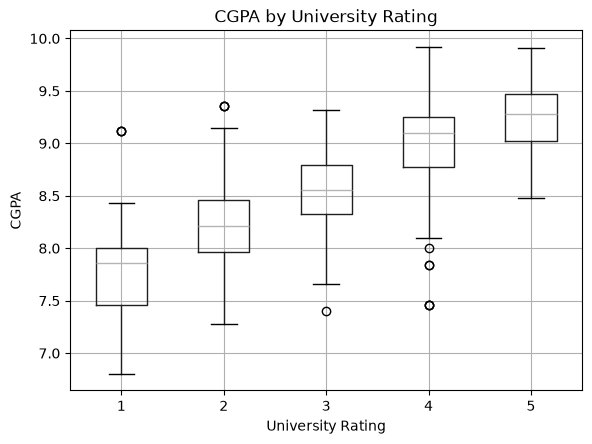

In [61]:
# distribución de CGPA por University Rating

admission_df.boxplot(
    column="CGPA",
    by="University Rating"
)

plt.title("CGPA by University Rating")
plt.suptitle("")
plt.xlabel("University Rating")
plt.ylabel("CGPA")
plt.show()

In [62]:
# promedio de CGPA por University Rating

admission_df.groupby(
    "University Rating",
    observed=True
)["CGPA"].mean().round(2)

University Rating
1   7.82
2   8.22
3   8.56
4   9.02
5   9.24
Name: CGPA, dtype: float64

## Research vs CGPA

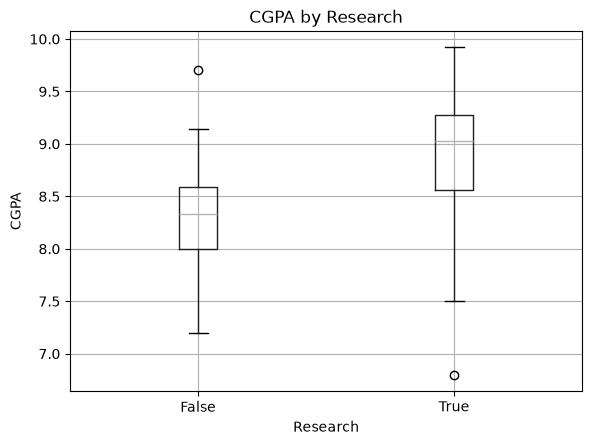

In [63]:
# distribución de CGPA por Research

admission_df.boxplot(
    column="CGPA",
    by="Research"
)

plt.title("CGPA by Research")
plt.suptitle("")
plt.xlabel("Research")
plt.ylabel("CGPA")
plt.show()

In [64]:
# promedio de CGPA por Research

admission_df.groupby(
    "Research",
    observed=True
)["CGPA"].mean().round(2)

Research
False   8.28
True    8.92
Name: CGPA, dtype: float64

## 📊 Analysis of Results and Conclusions 

## Conclusiones del análisis bivariable

El análisis bivariable permitió identificar asociaciones entre la variable objetivo `Chance of Admit` y las demás variables del conjunto de datos.

Entre las variables numéricas, `CGPA` presentó la mayor correlación con `Chance of Admit` (0.88), seguida de `GRE Score` (0.82) y `TOEFL Score` (0.81). Estas relaciones son positivas y fuertes, indicando que valores más altos en estas variables tienden a estar asociados con mayores probabilidades de admisión.

Las variables ordinales `University Rating`, `SOP` y `LOR` también mostraron un comportamiento creciente respecto a `Chance of Admit`. En general, las categorías superiores presentan mayores probabilidades promedio de admisión.

La variable `Research` mostró diferencias entre sus dos categorías. Los aspirantes con experiencia en investigación presentaron una probabilidad promedio de admisión mayor que aquellos sin experiencia en investigación.

También se identificaron asociaciones entre las variables predictoras. Las variables numéricas `GRE Score`, `TOEFL Score` y `CGPA` presentan correlaciones altas entre sí, mientras que `University Rating` mostró asociaciones con variables como `SOP`, `LOR` y `CGPA`.

Los boxplots evidenciaron algunas observaciones potencialmente atípicas dentro de determinados grupos. Estos valores no serán eliminados automáticamente, debido a que pueden corresponder a observaciones válidas. Su influencia deberá ser evaluada durante la preparación y modelado de los datos.

Los resultados obtenidos permiten identificar variables potencialmente relevantes para las siguientes etapas del proyecto. Sin embargo, las asociaciones observadas en este análisis no implican relaciones causales.
